# Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
import matplotlib as mpl

# Global settings for publication-quality plots
mpl.rcParams.update({
    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "stix",
    "font.size": 9,          # Base font size
    "axes.titlesize": 10,    # Title font size
    "axes.labelsize": 9,     # X/Y label font size
    "xtick.labelsize": 8,    # Tick label font size
    "ytick.labelsize": 8,
    "legend.fontsize": 8,    # Legend font size

    # Line styles
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Figure
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "figure.figsize": (3.3, 2.5),  # ~1-column figure in most journals
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})


# Check umbrella coverage

In [3]:
dirs = []
for d in os.listdir('.'):
    if d.endswith('.dat'):
        dirs.append(d)
dirs = sorted(dirs, key=lambda x: int(x.split('_')[2].split('.')[0]))

trajx = []
trajy = []
for d in dirs:
    print(f"Loading {d}")
    data = np.loadtxt(d)
    trajx.append(data[:,1])
    trajy.append(data[:,2])

Loading traj2d_window_00.dat
Loading traj2d_window_01.dat
Loading traj2d_window_02.dat
Loading traj2d_window_03.dat
Loading traj2d_window_04.dat
Loading traj2d_window_05.dat
Loading traj2d_window_06.dat
Loading traj2d_window_07.dat
Loading traj2d_window_08.dat
Loading traj2d_window_09.dat
Loading traj2d_window_10.dat
Loading traj2d_window_11.dat
Loading traj2d_window_12.dat
Loading traj2d_window_13.dat
Loading traj2d_window_14.dat
Loading traj2d_window_15.dat
Loading traj2d_window_16.dat
Loading traj2d_window_17.dat
Loading traj2d_window_18.dat
Loading traj2d_window_19.dat
Loading traj2d_window_20.dat
Loading traj2d_window_21.dat
Loading traj2d_window_22.dat
Loading traj2d_window_23.dat
Loading traj2d_window_24.dat
Loading traj2d_window_25.dat
Loading traj2d_window_26.dat
Loading traj2d_window_27.dat
Loading traj2d_window_28.dat
Loading traj2d_window_29.dat
Loading traj2d_window_30.dat
Loading traj2d_window_31.dat
Loading traj2d_window_32.dat
Loading traj2d_window_33.dat
Loading traj2d

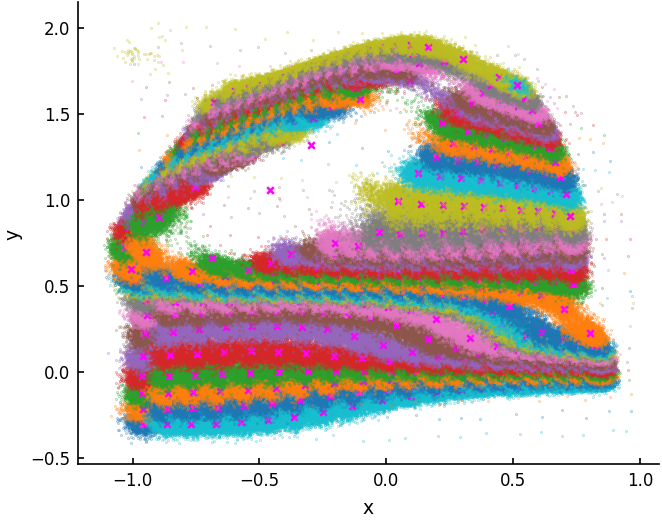

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=150)
for traj1, traj2 in zip(trajx[:], trajy[:]):
    ax.scatter(traj1, traj2, alpha=0.5,s=0.1)
    ax.scatter(traj1.mean(), traj2.mean(), color='magenta', marker='x', s=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.show()

# Run WHAM

In [ ]:
!python -m pywham.wham2d ../wham2d_config.yaml > /dev/null

In [6]:
free = np.loadtxt('output.free')

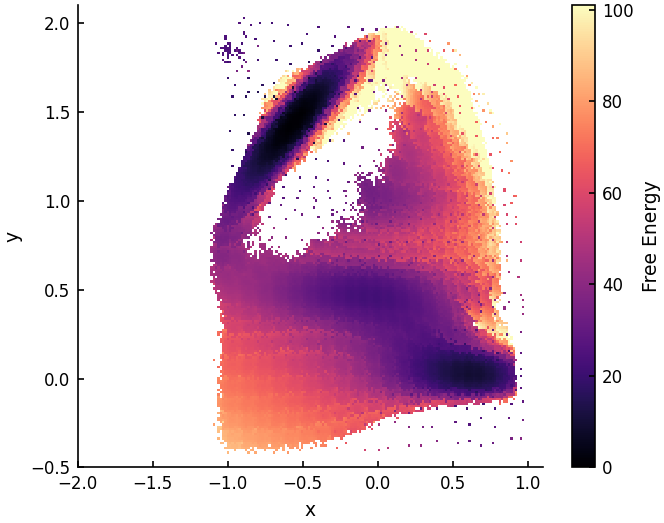

In [7]:
X, Y = np.meshgrid(np.unique(free[:,0]), np.unique(free[:,1]))
Z = free[:,2].reshape(X.shape)
#Z = np.where(Z > 101, np.inf, Z)

fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=150)
c = ax.pcolormesh(X, Y, Z.T, shading='auto', cmap='magma', vmax=101)
fig.colorbar(c, ax=ax, label='Free Energy')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()